# ENGR 1451/2451 — Weekly Assignment 4
**10 points**

This assignment applies measurement-error ideas, pandas data manipulation, and scatterplots and time trends.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.

## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.

## Setup

All data are synthetic teaching examples. LE4-1 and LE4-2 use data embedded in this notebook.
For LE4-3 and LE4-4, place the supplied `buildings.csv` file in a `data/` subfolder beside this notebook:

```text
LE04.ipynb
data/
    buildings.csv
```

Run the notebook with its containing folder as the working directory so that
`data/buildings.csv` points to the supplied file.

Use sample standard deviation $s$ (`ddof=1`). Select rows by conditions, not row positions,
and calculate counts and the latest year from the data. Use the supplied settings for thresholds.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

## LE4-1. Comparing two measuring instruments (2 pts)

Two instruments repeatedly measure the same reference block. Treat its certified length,
**25.000 mm**, as exact for this exercise.

### A. Precision and estimated bias (1 pt)

Create a table showing the **mean**, **sample standard deviation**, and **estimated bias**
for each instrument. Here, estimated bias is the sample mean minus the reference length.
Which instrument is more precise? Which sample mean is closer to the reference?

**Answer:** Instrument A has a higher precision since its standard deviation (0.015811) is lower than that of measurement B (0.072725); however, instrument B is more accurate beacause the sample mean of its measurements matches the reference value, whereas measurment A's sample mean does not. (Sample mean of B is closest to the reference)

In [70]:
reference_mm = 25.000
calibration = pd.DataFrame({
    "A_mm": [25.12, 25.10, 25.14, 25.11, 25.13,
             25.09, 25.12, 25.11, 25.13, 25.10],
    "B_mm": [24.92, 25.06, 24.97, 25.12, 24.89,
             25.03, 25.08, 24.95, 25.00, 24.98],
})

# Your summary table here. Report lengths, s, and estimated bias in mm.
mean_A = calibration["A_mm"].mean()
mean_B = calibration["B_mm"].mean()
std_A = calibration["A_mm"].std()
std_B = calibration["B_mm"].std()
est_bias_A = mean_A - reference_mm
est_bias_B = mean_B - reference_mm

display_table_LE41A = pd.DataFrame({
    "Mean":[mean_A,mean_B],
    "STD":[std_A,std_B],
    "Estimated Bias":[est_bias_A,est_bias_B],  
},index = ["A_mm","B_mm"])

display_table_LE41A

,Mean,STD,Estimated Bias
A_mm,25.115,0.015811,0.115
B_mm,25.000,0.072725,0.000


### B. Apply a calibration correction (1 pt)

Subtract A's estimated bias from every A reading and store the result in `corrected_A`.
Compare its mean and sample $s$ with the original A readings.

What changed, and what stayed the same? Would simply collecting more **uncorrected**
readings remove a persistent bias?

**Answer:** After subtracting A's estimated bias from every reading, the sample mean of A now matches the reference value, and thus the estimated bias becomes 0. The standard deviation remains unchanged as a result of this. Collecting more uncorrected readings would not remove a persistent bias because bias does not go away with higher sample sizes; bias is a persistent error that must be corrected (recalibration, tuning, etc.) in order to go away.

In [ ]:
# Your correction and comparison here
corrected_A = calibration["A_mm"] - est_bias_A

mean_corrected_A = corrected_A.mean()
std_corrected_A = corrected_A.std()
est_bias_corrected_A = mean_corrected_A - reference_mm

corrected_A_df = pd.DataFrame({
    "Mean":[mean_corrected_A],
    "STD":[std_corrected_A],
    "Estimated Bias":[est_bias_corrected_A],  
},index = ["Corrected_A"])

display_table_LE41B = pd.concat([display_table_LE41A,corrected_A_df])

display_table_LE41B

,Mean,STD,Estimated Bias
A_mm,25.115,0.015811,0.115
B_mm,25.000,0.072725,0.000
Corrected_A,25.000,0.015811,0.000


## LE4-2. Investigating unusual resistance readings (3 pts)

An instrument repeatedly measures the same nominal 100-ohm resistor under stable conditions.
Its exact resistance is unknown. An independent equipment log documents a **loose electrical
lead during one reading**; the other readings have no documented fault.

### A. Flag observations for investigation (1 pt)

Calculate $Q_1$, $Q_3$, and the IQR. Flag readings outside
$[Q_1-1.5\,\mathrm{IQR},\ Q_3+1.5\,\mathrm{IQR}]$ with a Boolean mask called `is_outlier`.
Display their reading IDs, resistance values, and log status. Use `.loc[]` and retain the original data.

In [67]:
resistance_values = np.array([
    100.1, 99.9, 100.0, 100.2, 100.1, 99.8, 100.0, 100.1, 102.4, 99.9,
    100.2, 100.0, 99.8, 100.1, 100.0, 100.2, 100.1, 101.1, 99.9, 100.0,
])
log_status = [
    "none", "none", "none", "none", "none", "none", "none", "none", "loose_lead", "none",
    "none", "none", "none", "none", "none", "none", "none", "none", "none", "none",
]
readings = pd.DataFrame({
    "reading_id": [f"R{number:02d}" for number in range(1, len(resistance_values) + 1)],
    "resistance_ohm": resistance_values,
    "log_status": log_status,
})
resistance_settings = {
    "outlier_multiplier": 1.5,
    "fault_status": "loose_lead",
    "lower_ohm": 99.8,
    "upper_ohm": 100.2,
}

# Your IQR calculation, Boolean mask, and flagged-reading table here
resist_vals_q1,resist_vals_q3 = readings["resistance_ohm"].quantile([0.25,0.75])
resist_vals_IQR = resist_vals_q3 - resist_vals_q1
resist_vals_IQR_threshold = resist_vals_IQR * 1.5
resist_vals_lower_bound = resist_vals_q1 - resist_vals_IQR_threshold
resist_vals_upper_bound = resist_vals_q3 + resist_vals_IQR_threshold
is_outlier = (readings["resistance_ohm"] > resist_vals_upper_bound) | (readings["resistance_ohm"] < resist_vals_lower_bound)
readings.loc[is_outlier]

,reading_id,resistance_ohm,log_status
8,R09,102.4,loose_lead
17,R18,101.1,none


### B. Exclude a documented failure (1 pt)

Create `retained_readings` by excluding **only the reading with the logged loose lead**.
Select it by `log_status`, not by its row position or resistance value.
Compare the count, mean, and sample $s$ for all readings and the retained readings in one table.

Compare the absolute changes, in ohms, in the mean and $s$. Which is larger?
Does an IQR flag alone justify excluding the other unusual reading? Explain briefly.

**Answer:** The largest absolute change in ohms was the standard deviation (with the retained readings' std being lower by 0.3). An IQR flag alone does not justifiy excluding the other reading because it is still possible for that outlier to have occured simply due to random variation. It is not good statistical practice to remove outliers just to make the summary statistics look better.

In [66]:
# Your retained subset and summary comparison here
retained_readings = readings.loc[readings["log_status"]!="loose_lead"]
summary_retained = retained_readings["resistance_ohm"].agg(["count","mean","std"]).rename("Retained Readings")
summary_initial = readings["resistance_ohm"].agg(["count","mean","std"]).rename("Initial Readings")
abs_changes = abs(summary_initial - summary_retained).rename("Absolute Changes")

display_table_LE42B = pd.concat([summary_initial,summary_retained,abs_changes],axis=1)

display_table_LE42B

,Initial Readings,Retained Readings,Absolute Changes
count,20.000000,19.000000,1.000000
mean,100.195000,100.078947,0.116053
std,0.584425,0.276041,0.308384


### C. Check a normal approximation (1 pt)

Use **all retained readings from Part B**, including any still flagged by the IQR rule.
Fit a normal model using their calculated mean and sample $s$.

For the interval **99.8 to 100.2 ohms, including both endpoints**, report the observed
percentage using a Boolean mask and the normal-model percentage using `norm.cdf()`.
Is the model percentage too low, too high, or close for this interval?
Why would even a good normal fit fail to establish that the instrument is unbiased?

**Answer:** The model percentage is much too low for this interval. Even a normal fit will fail to establish that an instrument is unbiased because it has no way of assesing the accuracy of measurements (or how far they are from the exact value of the measurement) by simply looking at the obtained readings. 

In [75]:
# Your observed percentage and normal approximation here
upper_bound_resistance = 100.2
lower_bound_resistance = 99.8
model_LE42C = norm(loc = summary_retained["mean"], scale = summary_retained["std"])
interval_LE42C_norm = (model_LE42C.cdf(upper_bound_resistance) - model_LE42C.cdf(lower_bound_resistance))*100 #scaling to percentage
mask_LE42C = (retained_readings["resistance_ohm"] <= upper_bound_resistance) & (retained_readings["resistance_ohm"] >= lower_bound_resistance)
interval_LE42C_observed = (retained_readings["resistance_ohm"].loc[mask_LE42C].count() / summary_retained["count"]) *100 #finding proportion and scaling to percentage

print("Normal model result (%) = ", interval_LE42C_norm,
      "\nObserved percentage = ", interval_LE42C_observed)

Normal model result (%) =  51.33778920512899 
Observed percentage =  94.73684210526315


## LE4-3. Build an electricity-use comparison table (3 pts)

Each row in `data/buildings.csv` describes **one building in one year**. `floor_area_m2` is floor area in
square meters, and `electricity_kWh` is total electricity used during that year.

### A. Create a column and select a year (1 pt)

Run the code below to read `data/buildings.csv` into `buildings`.
Use `.assign()` to create a DataFrame called `energy`
with a new column, `energy_intensity`, calculated as

$$
\text{energy intensity} = \frac{\text{electricity use (kWh)}}{\text{floor area (m}^2\text{)}}.
$$

Find the latest year in the data and create `latest`, a copy containing that year only.
Display building name, use, floor area, and energy intensity for this snapshot.

In [91]:
buildings = pd.read_csv("data/buildings.csv")

energy_settings = {
    "minimum_area_m2": 3000,
    "high_intensity_kWh_m2": 180,
    "trend_building": "Maple",
}

# Your derived column, latest-year selection, and display here
energy_intensity = buildings["electricity_kWh"] / buildings["floor_area_m2"]
energy = buildings.assign(energy_intensity=energy_intensity)
latest_year = buildings["year"].max()
latest = energy.loc[energy["year"]==latest_year]
latest[["building", "use", "floor_area_m2", "energy_intensity"]] #displaying data

,building,use,floor_area_m2,energy_intensity
0,Birch,Office,400,160.0
3,Cedar,Laboratory,1200,190.0
6,Maple,Office,3200,110.0
9,Oak,Laboratory,8000,220.0
12,Pine,Office,16000,90.0
15,Willow,Laboratory,32000,190.0


### B. Filter and sort (1 pt)

From `latest`, select buildings with floor area **at least 3,000 m²** and energy intensity
**greater than 180 kWh/m²** for the year. Use a compound Boolean condition with `.loc[]`.
Show `building`, `use`, and `energy_intensity`, sorted from highest to lowest intensity.

In [94]:
# Your filtered and sorted table here
latest_mask = (latest["floor_area_m2"] >= 3000) & (latest["energy_intensity"] > 180)
latest_sorted = latest.loc[latest_mask].sort_values("energy_intensity",ascending=False) #sorting from highest to lowest, descending order
latest_sorted[["building","use","energy_intensity"]] #display

,building,use,energy_intensity
9,Oak,Laboratory,220.0
15,Willow,Laboratory,190.0


### C. Group and summarize (1 pt)

Using **all buildings in `latest`**, create one row per building `use` with the number
of buildings and mean energy intensity. Use `.groupby(...).agg(...)` with descriptive column names.

Which use has the larger mean? Does this calculation give equal weight to each building
or to each square meter of floor area?

**Answer:** Labratory has the larger mean energy intensity. This calculation gives equal weight to each building because of the way the mean is calculated. The mean gives each value equal weight regardless of how it was calculated. To give equal weight to based on square meter of floor area, you would need to take the sum of the total floor area across all buildings and multiply each building's energy_intensity by its respective floor area divided by the total floor area in the calculation for the mean.

In [104]:
# Your grouped summary here
latest.groupby("use")["energy_intensity"].agg(
    n_buildings=("count"),
    mean_energy_intensity=("mean")).reset_index()

,use,n_buildings,mean_energy_intensity
0,Laboratory,3,200.0
1,Office,3,120.0


## LE4-4. Show a relationship and a time trend (2 pts)

Use `energy` and `latest` from LE4-3. Label axes with units and give each plot a title.

### A. Scatterplot with a log axis (1 pt)

For **all buildings in `latest`**, plot floor area on the x-axis and energy intensity
on the y-axis. Use `ax.set_xscale("log")` because floor areas span a wide range.

Explain what equal horizontal distances represent. Does the largest building have the
highest energy intensity in this snapshot?

**Answer:** Equal horizontal distances represent an increase in the floor area by the same factor (ex. by a factor of 10 for each labeled tickmark on the x-axis).
By examining the plot, the largest building does not have the highest enery intensity in this snapshot.

Text(0.5, 1.0, 'Energy Intensity vs Floor Area for 2025')

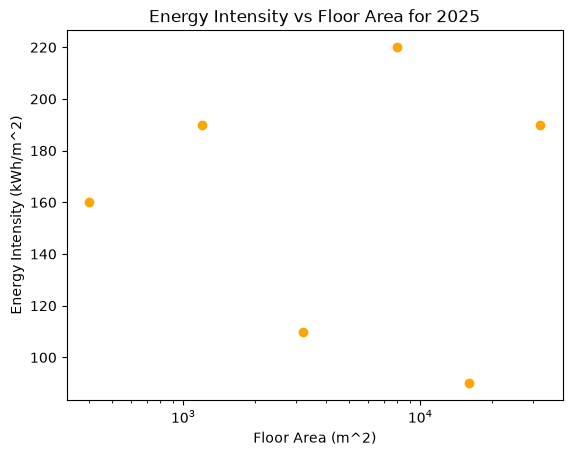

In [124]:
# Your scatterplot here
fig, ax = plt.subplots()
ax.scatter(latest["floor_area_m2"],latest["energy_intensity"],color = "orange")
ax.set_xscale("log")
ax.set_ylabel("Energy Intensity (kWh/m^2)")
ax.set_xlabel("Floor Area (m^2)")
ax.set_title("Energy Intensity vs Floor Area for " + str(latest_year)) #Automatically adding the latest year to the label (good coding practice)

### B. Follow one building over time (1 pt)

From the full `energy` table, select the building named in `energy_settings["trend_building"]`.
Sort its rows by year before making a line plot of energy intensity versus year, with a marker
at each observed year. Use a linear year axis.

Describe the trend. Would this plot alone establish that an energy-saving renovation caused
the change? Give one reason for your answer.

**Answer:** The plot's trend in energy intensity is decreasing with respect to year. In order to establish that the energy saving renovation caused the change, the plot alone would not suffice. In order to prove that the energy intensity is decreasing as the years are decreasing, more data points would be needed, and an experiment would need to be conducted to rule out the prescence of any cofounding variables.

Text(0, 0.5, 'Energy Intensity (kWh/m^2)')

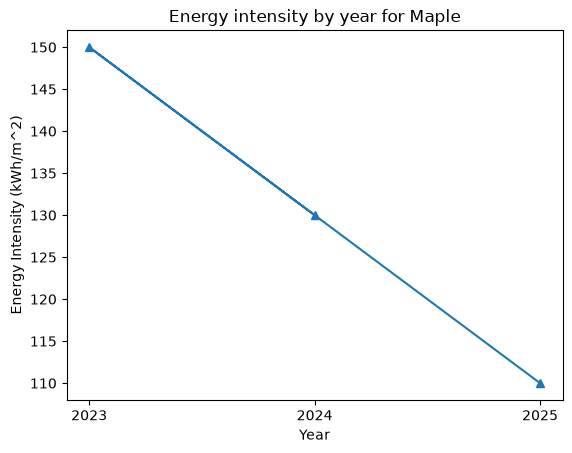

In [136]:
# Your selected, sorted data and time plot here
trend_building_table = energy.loc[energy["building"]==energy_settings["trend_building"]]
trend_building_table.sort_values("year")

fig, ax = plt.subplots()
ax.plot(trend_building_table["year"],trend_building_table["energy_intensity"],marker = "^")
ax.set_xticks(trend_building_table["year"])
ax.set_title("Energy intensity by year for "+energy_settings["trend_building"])
ax.set_xlabel("Year")
ax.set_ylabel("Energy Intensity (kWh/m^2)")

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA4",
  "export_n": 1,
  "session_date": "2026-09-27",
  "messages": [
    {"i": 1, "who": "student", "text": "Good afternoon! I forget which library requires std(ddof=1) and does not assume to be taking the sample std. Does pandas need the ddof=1?"},
    {"i": 2, "who": "tutor", "text": "NumPy defaults to population std (ddof=0); pandas defaults to sample std (ddof=1) automatically. [trimmed]"},
    {"i": 3, "who": "student", "text": "can pandas columns be scaled and added to like an array?"},
    {"i": 4, "who": "tutor", "text": "Explained elementwise arithmetic on Series, column-with-column vs column-with-scalar, alignment by index, .assign() vs direct assignment. [trimmed]"},
    {"i": 5, "who": "student", "text": "How could I add a column to a preexisting pandas dataframe?"},
    {"i": 6, "who": "tutor", "text": "Explained direct assignment, .assign(), .insert(), and the mutate-vs-new-DataFrame distinction. [trimmed]"},
    {"i": 7, "who": "student", "code": true, "text": "Can you help me troubleshoot this?\n\n```python\n# Your correction and comparison here\ncorrected_A = calibration[\"A_mm\"] - est_bias_A\n\nmean_corrected_A = corrected_A.mean()\nstd_corrected_A = corrected_A.std(ddof=1)\nest_bias_corrected_A = reference_mm - mean_corrected_A\n\ndisplay_table_LE41B = display_table_LE41A.assign({\"corrected_A\":[mean_corrected_A,std_corrected_A,est_bias_corrected_A]})\n```\n\nTypeError: DataFrame.assign() takes 1 positional argument but 2 were given"},
    {"i": 8, "who": "tutor", "text": "Explained .assign() needs keyword args, not a dict positional arg. Also flagged to check sign convention on est_bias_corrected_A against the reference/mean definition. [trimmed]"},
    {"i": 9, "who": "student", "code": true, "text": "ValueError: Length of values (3) does not match length of index (2), traceback showing display_table_LE41A.assign(corrected_A=[mean_corrected_A,std_corrected_A,est_bias_corrected_A]) failing."},
    {"i": 10, "who": "tutor", "text": "Asked to see the structure of display_table_LE41A (shape/index) to diagnose the shape mismatch rather than patch it blindly."},
    {"i": 11, "who": "student", "code": true, "text": "display_table_LE41A = pd.DataFrame({\n    \"Mean\":[mean_A,mean_B],\n    \"STD\":[std_A,std_B],\n    \"Estimated Bias\":[est_bias_A,est_bias_B],  \n},index = [\"A_mm\",\"B_mm\"])"},
    {"i": 12, "who": "tutor", "text": "Explained the row-vs-column mismatch: table has instruments as rows, stats as columns; corrected_A's 3 values are a row's worth, not a column's worth. Suggested building a fresh 2-row comparison table instead. [trimmed]"},
    {"i": 13, "who": "student", "text": "What command could I use to add a row instead of another column?"},
    {"i": 14, "who": "tutor", "text": "Explained pd.concat() for stacking a new one-row DataFrame onto an existing one, matching column names, returns new DataFrame. [trimmed]"},
    {"i": 15, "who": "student", "text": "Can you remind me of how to create a boolean mask?"},
    {"i": 16, "who": "tutor", "text": "Explained building a mask via comparison, using .loc[] to select, & | ~ with parentheses, .sum()/.mean() for counts and proportions. [trimmed]"},
    {"i": 17, "who": "student", "text": "would I use || for adding an or to the mask?"},
    {"i": 18, "who": "tutor", "text": "Clarified || is invalid Python/pandas syntax; use single | for elementwise or; contrasted with plain Python or on Series raising ValueError. [trimmed]"},
    {"i": 19, "who": "student", "text": "How would the syntax change for a pandas series?"},
    {"i": 20, "who": "tutor", "text": "Clarified df[\"value\"] already is a Series, so syntax is identical; no separate Series version to learn."},
    {"i": 21, "who": "student", "code": true, "text": "Is the following code what is meant by selecting the loose lead value by log status?\n\n```python\n# Your retained subset and summary comparison here\nretained_readings = readings.loc[readings[\"log_status\"]!=\"loose_lead\"]\n```"},
    {"i": 22, "who": "tutor", "text": "Confirmed correct approach — selecting by log_status column rather than position/value. Suggested adding .copy() as a habit against SettingWithCopyWarning."},
    {"i": 23, "who": "student", "code": true, "text": "Was there a more efficient way of writing this code?\n\n```python\nmean_A = calibration[\"A_mm\"].mean()\nmean_B = calibration[\"B_mm\"].mean()\nstd_A = calibration[\"A_mm\"].std(ddof=1)\nstd_B = calibration[\"B_mm\"].std(ddof=1)\nest_bias_A = mean_A - reference_mm\nest_bias_B = mean_B - reference_mm\n\ndisplay_table_LE41A = pd.DataFrame({\n    \"Mean\":[mean_A,mean_B],\n    \"STD\":[std_A,std_B],\n    \"Estimated Bias\":[est_bias_A,est_bias_B],  \n},index = [\"A_mm\",\"B_mm\"])\n```"},
    {"i": 24, "who": "tutor", "text": "Explained .agg([\"mean\",\"std\"]) as a more compact alternative, noted layout is transposed relative to their table, confirmed their version is correct as-is. [trimmed]"},
    {"i": 25, "who": "student", "text": "I am getting a type error when I use .agg()"},
    {"i": 26, "who": "tutor", "text": "Asked for the exact code and full traceback."},
    {"i": 27, "who": "student", "code": true, "text": "```python\n# Your retained subset and summary comparison here\nretained_readings = readings.loc[readings[\"log_status\"]!=\"loose_lead\"]\nretained_readings.agg([\"count\",\"mean\",\"std\"])\n```"},
    {"i": 28, "who": "tutor", "text": "Guessed the issue: .agg() applied to whole DataFrame including text columns (reading_id, log_status) can't take mean/std of strings. Suggested narrowing to retained_readings[\"resistance_ohm\"].agg([...]) and asked for traceback to confirm."},
    {"i": 29, "who": "student", "text": "TypeError traceback: Cannot perform reduction 'mean' with string dtype (full traceback pasted)."},
    {"i": 30, "who": "tutor", "text": "Confirmed diagnosis matched the traceback; gave the fix: retained_readings[\"resistance_ohm\"].agg([\"count\",\"mean\",\"std\"])."},
    {"i": 31, "who": "student", "code": true, "text": "How can I bring these two summary variables together to make a table?\n\n```python\nsummary_1 = retained_readings[\"resistance_ohm\"].agg([\"count\",\"mean\",\"std\"])\nsummary_2 = readings[\"resistance_ohm\"].agg([\"count\",\"mean\",\"std\"])\n```"},
    {"i": 32, "who": "tutor", "text": "Gave two options: pd.concat([...], axis=1) with renamed columns, or building a fresh DataFrame from a dict of the two Series. [trimmed]"},
    {"i": 33, "who": "student", "text": "Is there a way I can retitle the columns of each summary series to be able to distinguish them better?"},
    {"i": 34, "who": "tutor", "text": "Explained Series.rename() to set .name, and that pd.concat then uses those names as column labels automatically. [trimmed]"},
    {"i": 35, "who": "student", "text": "For LE4 2C, do I need to create a visual normal fit, or just a normal model to get the interval's normal model percentage?"},
    {"i": 36, "who": "tutor", "text": "Clarified no plot needed — just norm(loc=mean, scale=std) and two cdf() calls subtracted for the model percentage; observed percentage from a Boolean mask with inclusive endpoints. [trimmed]"},
    {"i": 37, "who": "student", "text": "Also does .agg() assume ddof = 1 for std?"},
    {"i": 38, "who": "tutor", "text": "Confirmed yes — .agg(\"std\") calls pandas' own .std(), same ddof=1 default; only NumPy's own std defaults to ddof=0."},
    {"i": 39, "who": "student", "text": "Does norm.cdf() account for endpoints by default?"},
    {"i": 40, "who": "tutor", "text": "Explained continuous distributions give P(X=b)=0, so cdf(b)-cdf(a) is endpoint-agnostic for the model; but the observed mask on real data must use >= and <= per the inclusive interval wording."},
    {"i": 41, "who": "student", "text": "For LE4 2C, is it expected that the normal model will significantly underestimate the percentage? I got a large difference in values and it is making me second guess my answers."},
    {"i": 42, "who": "tutor", "text": "Asked two clarifying questions: which set was the model fitted to, and whether the observed mask used inclusive or strict inequalities, before judging the gap."},
    {"i": 43, "who": "student", "code": true, "text": "```python\nupper_bound_resistance = 100.2\nlower_bound_resistance = 99.8\nmodel_LE42C = norm(loc = summary_retained[\"mean\"], scale = summary_retained[\"std\"])\ninterval_LE42C_norm = (model_LE42C.cdf(upper_bound_resistance) - model_LE42C.cdf(lower_bound_resistance))*100 #scaling to percentage\nmask_LE42C = (retained_readings[\"resistance_ohm\"] <= upper_bound_resistance) & (retained_readings[\"resistance_ohm\"] >= lower_bound_resistance)\ninterval_LE42C_observed = (retained_readings[\"resistance_ohm\"].loc[mask_LE42C].count() / summary_retained[\"count\"]) *100 #finding proportion and scaling to percentage\n\nprint(\"Normal model result (%) = \", interval_LE42C_norm,\n      \"\\nObserved percentage = \", interval_LE42C_observed)\n```"},
    {"i": 44, "who": "tutor", "text": "Confirmed both checks passed (correct set fitted, inclusive mask). Ran a reference computation (mean≈100.079, s≈0.276, model≈51.3%, observed≈94.7%) confirming a large gap is expected due to one wide-spread reading (101.1) inflating s. Connected this to the written too-low/too-high and unbiasedness questions."},
    {"i": 45, "who": "student", "text": "I got those values! Thank you for helping me check my work :)"},
    {"i": 46, "who": "tutor", "text": "Confirmed part C code is solid; asked whether to continue to LE4-3 or wrap up."},
    {"i": 47, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 11, "part": "4-1A", "type": "code"},
    {"i": 23, "part": "4-1A", "type": "part_pass"},
    {"i": 7, "part": "4-1B", "type": "code"},
    {"i": 9, "part": "4-1B", "type": "code"},
    {"i": 14, "part": "4-1B", "type": "part_pass"},
    {"i": 21, "part": "4-2B", "type": "code"},
    {"i": 22, "part": "4-2B", "type": "part_pass"},
    {"i": 27, "part": "4-2B", "type": "code"},
    {"i": 31, "part": "4-2B", "type": "code"},
    {"i": 43, "part": "4-2C", "type": "code"},
    {"i": 44, "part": "4-2C", "type": "part_pass"}
  ],
  "parts": [
    {"part": "4-1A", "exchanges": 2, "max_tier": 2, "passed": true},
    {"part": "4-1B", "exchanges": 4, "max_tier": 3, "passed": true},
    {"part": "4-2B", "exchanges": 5, "max_tier": 3, "passed": true},
    {"part": "4-2C", "exchanges": 4, "max_tier": 2, "passed": true}
  ],
  "tutor_assessment": [
    "The student stalled longest on LE4-2B: building corrected_A's comparison table (row-vs-column shape mismatch, then a TypeError from calling .agg() on non-numeric columns) took several genuine debugging exchanges before landing on a clean per-column .agg() plus pd.concat() approach; LE4-2C's large model-vs-observed gap was resolved quickly once the fitted set and mask inclusivity were confirmed.",
    "No unstuck declarations or release-valve use this session; the student worked through each error with real code and tracebacks, so no concern about tutoring effectiveness here."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA4",
  "export_n": 2,
  "session_date": "2026-09-27",
  "messages": [
    {"i": 1, "who": "student", "text": "Good afternoon! I forget which library requires std(ddof=1) and does not assume to be taking the sample std. Does pandas need the ddof=1?"},
    {"i": 2, "who": "tutor", "text": "NumPy defaults to population std (ddof=0); pandas defaults to sample std (ddof=1) automatically. [trimmed]"},
    {"i": 3, "who": "student", "text": "can pandas columns be scaled and added to like an array?"},
    {"i": 4, "who": "tutor", "text": "Explained elementwise arithmetic on Series, column-with-column vs column-with-scalar, alignment by index, .assign() vs direct assignment. [trimmed]"},
    {"i": 5, "who": "student", "text": "How could I add a column to a preexisting pandas dataframe?"},
    {"i": 6, "who": "tutor", "text": "Explained direct assignment, .assign(), .insert(), and the mutate-vs-new-DataFrame distinction. [trimmed]"},
    {"i": 7, "who": "student", "code": true, "text": "Can you help me troubleshoot this?\n\n```python\n# Your correction and comparison here\ncorrected_A = calibration[\"A_mm\"] - est_bias_A\n\nmean_corrected_A = corrected_A.mean()\nstd_corrected_A = corrected_A.std(ddof=1)\nest_bias_corrected_A = reference_mm - mean_corrected_A\n\ndisplay_table_LE41B = display_table_LE41A.assign({\"corrected_A\":[mean_corrected_A,std_corrected_A,est_bias_corrected_A]})\n```\n\nTypeError: DataFrame.assign() takes 1 positional argument but 2 were given"},
    {"i": 8, "who": "tutor", "text": "Explained .assign() needs keyword args, not a dict positional arg. Also flagged to check sign convention on est_bias_corrected_A against the reference/mean definition. [trimmed]"},
    {"i": 9, "who": "student", "code": true, "text": "ValueError: Length of values (3) does not match length of index (2), traceback showing display_table_LE41A.assign(corrected_A=[mean_corrected_A,std_corrected_A,est_bias_corrected_A]) failing."},
    {"i": 10, "who": "tutor", "text": "Asked to see the structure of display_table_LE41A (shape/index) to diagnose the shape mismatch rather than patch it blindly."},
    {"i": 11, "who": "student", "code": true, "text": "display_table_LE41A = pd.DataFrame({\n    \"Mean\":[mean_A,mean_B],\n    \"STD\":[std_A,std_B],\n    \"Estimated Bias\":[est_bias_A,est_bias_B],  \n},index = [\"A_mm\",\"B_mm\"])"},
    {"i": 12, "who": "tutor", "text": "Explained the row-vs-column mismatch: table has instruments as rows, stats as columns; corrected_A's 3 values are a row's worth, not a column's worth. Suggested building a fresh 2-row comparison table instead. [trimmed]"},
    {"i": 13, "who": "student", "text": "What command could I use to add a row instead of another column?"},
    {"i": 14, "who": "tutor", "text": "Explained pd.concat() for stacking a new one-row DataFrame onto an existing one, matching column names, returns new DataFrame. [trimmed]"},
    {"i": 15, "who": "student", "text": "Can you remind me of how to create a boolean mask?"},
    {"i": 16, "who": "tutor", "text": "Explained building a mask via comparison, using .loc[] to select, & | ~ with parentheses, .sum()/.mean() for counts and proportions. [trimmed]"},
    {"i": 17, "who": "student", "text": "would I use || for adding an or to the mask?"},
    {"i": 18, "who": "tutor", "text": "Clarified || is invalid Python/pandas syntax; use single | for elementwise or; contrasted with plain Python or on Series raising ValueError. [trimmed]"},
    {"i": 19, "who": "student", "text": "How would the syntax change for a pandas series?"},
    {"i": 20, "who": "tutor", "text": "Clarified df[\"value\"] already is a Series, so syntax is identical; no separate Series version to learn."},
    {"i": 21, "who": "student", "code": true, "text": "Is the following code what is meant by selecting the loose lead value by log status?\n\n```python\n# Your retained subset and summary comparison here\nretained_readings = readings.loc[readings[\"log_status\"]!=\"loose_lead\"]\n```"},
    {"i": 22, "who": "tutor", "text": "Confirmed correct approach — selecting by log_status column rather than position/value. Suggested adding .copy() as a habit against SettingWithCopyWarning."},
    {"i": 23, "who": "student", "code": true, "text": "Was there a more efficient way of writing this code?\n\n```python\nmean_A = calibration[\"A_mm\"].mean()\nmean_B = calibration[\"B_mm\"].mean()\nstd_A = calibration[\"A_mm\"].std(ddof=1)\nstd_B = calibration[\"B_mm\"].std(ddof=1)\nest_bias_A = mean_A - reference_mm\nest_bias_B = mean_B - reference_mm\n\ndisplay_table_LE41A = pd.DataFrame({\n    \"Mean\":[mean_A,mean_B],\n    \"STD\":[std_A,std_B],\n    \"Estimated Bias\":[est_bias_A,est_bias_B],  \n},index = [\"A_mm\",\"B_mm\"])\n```"},
    {"i": 24, "who": "tutor", "text": "Explained .agg([\"mean\",\"std\"]) as a more compact alternative, noted layout is transposed relative to their table, confirmed their version is correct as-is. [trimmed]"},
    {"i": 25, "who": "student", "text": "I am getting a type error when I use .agg()"},
    {"i": 26, "who": "tutor", "text": "Asked for the exact code and full traceback."},
    {"i": 27, "who": "student", "code": true, "text": "```python\n# Your retained subset and summary comparison here\nretained_readings = readings.loc[readings[\"log_status\"]!=\"loose_lead\"]\nretained_readings.agg([\"count\",\"mean\",\"std\"])\n```"},
    {"i": 28, "who": "tutor", "text": "Guessed the issue: .agg() applied to whole DataFrame including text columns (reading_id, log_status) can't take mean/std of strings. Suggested narrowing to retained_readings[\"resistance_ohm\"].agg([...]) and asked for traceback to confirm."},
    {"i": 29, "who": "student", "text": "TypeError traceback: Cannot perform reduction 'mean' with string dtype (full traceback pasted)."},
    {"i": 30, "who": "tutor", "text": "Confirmed diagnosis matched the traceback; gave the fix: retained_readings[\"resistance_ohm\"].agg([\"count\",\"mean\",\"std\"])."},
    {"i": 31, "who": "student", "code": true, "text": "How can I bring these two summary variables together to make a table?\n\n```python\nsummary_1 = retained_readings[\"resistance_ohm\"].agg([\"count\",\"mean\",\"std\"])\nsummary_2 = readings[\"resistance_ohm\"].agg([\"count\",\"mean\",\"std\"])\n```"},
    {"i": 32, "who": "tutor", "text": "Gave two options: pd.concat([...], axis=1) with renamed columns, or building a fresh DataFrame from a dict of the two Series. [trimmed]"},
    {"i": 33, "who": "student", "text": "Is there a way I can retitle the columns of each summary series to be able to distinguish them better?"},
    {"i": 34, "who": "tutor", "text": "Explained Series.rename() to set .name, and that pd.concat then uses those names as column labels automatically. [trimmed]"},
    {"i": 35, "who": "student", "text": "For LE4 2C, do I need to create a visual normal fit, or just a normal model to get the interval's normal model percentage?"},
    {"i": 36, "who": "tutor", "text": "Clarified no plot needed — just norm(loc=mean, scale=std) and two cdf() calls subtracted for the model percentage; observed percentage from a Boolean mask with inclusive endpoints. [trimmed]"},
    {"i": 37, "who": "student", "text": "Also does .agg() assume ddof = 1 for std?"},
    {"i": 38, "who": "tutor", "text": "Confirmed yes — .agg(\"std\") calls pandas' own .std(), same ddof=1 default; only NumPy's own std defaults to ddof=0."},
    {"i": 39, "who": "student", "text": "Does norm.cdf() account for endpoints by default?"},
    {"i": 40, "who": "tutor", "text": "Explained continuous distributions give P(X=b)=0, so cdf(b)-cdf(a) is endpoint-agnostic for the model; but the observed mask on real data must use >= and <= per the inclusive interval wording."},
    {"i": 41, "who": "student", "text": "For LE4 2C, is it expected that the normal model will significantly underestimate the percentage? I got a large difference in values and it is making me second guess my answers."},
    {"i": 42, "who": "tutor", "text": "Asked two clarifying questions: which set was the model fitted to, and whether the observed mask used inclusive or strict inequalities, before judging the gap."},
    {"i": 43, "who": "student", "code": true, "text": "```python\nupper_bound_resistance = 100.2\nlower_bound_resistance = 99.8\nmodel_LE42C = norm(loc = summary_retained[\"mean\"], scale = summary_retained[\"std\"])\ninterval_LE42C_norm = (model_LE42C.cdf(upper_bound_resistance) - model_LE42C.cdf(lower_bound_resistance))*100 #scaling to percentage\nmask_LE42C = (retained_readings[\"resistance_ohm\"] <= upper_bound_resistance) & (retained_readings[\"resistance_ohm\"] >= lower_bound_resistance)\ninterval_LE42C_observed = (retained_readings[\"resistance_ohm\"].loc[mask_LE42C].count() / summary_retained[\"count\"]) *100 #finding proportion and scaling to percentage\n\nprint(\"Normal model result (%) = \", interval_LE42C_norm,\n      \"\\nObserved percentage = \", interval_LE42C_observed)\n```"},
    {"i": 44, "who": "tutor", "text": "Confirmed both checks passed (correct set fitted, inclusive mask). Ran a reference computation (mean≈100.079, s≈0.276, model≈51.3%, observed≈94.7%) confirming a large gap is expected due to one wide-spread reading (101.1) inflating s. Connected this to the written too-low/too-high and unbiasedness questions."},
    {"i": 45, "who": "student", "text": "I got those values! Thank you for helping me check my work :)"},
    {"i": 46, "who": "tutor", "text": "Confirmed part C code is solid; asked whether to continue to LE4-3 or wrap up."},
    {"i": 47, "who": "student", "text": "make my record"},
    {"i": 48, "who": "tutor", "text": "[export_n=1 emitted]"},
    {"i": 49, "who": "student", "code": true, "text": "```python\nbuildings = pd.read_csv(\"data/buildings.csv\")\n\nenergy_settings = {\n    \"minimum_area_m2\": 3000,\n    \"high_intensity_kWh_m2\": 180,\n    \"trend_building\": \"Maple\",\n}\n\n# Your derived column, latest-year selection, and display here\nbuildings.head()\nenergy_intensity = buildings[\"electricity_kWh\"] / buildings[\"floor_area_m2\"]\nenergy = buildings.assign(energy_intensity)\n```\n\nTypeError: DataFrame.assign() takes 1 positional argument but 2 were given"},
    {"i": 50, "who": "tutor", "text": "Identified same root cause as earlier LE4-1B error: .assign() needs a keyword, not positional. Gave fix: buildings.assign(energy_intensity=energy_intensity). Asked to check units/column placement after running."},
    {"i": 51, "who": "student", "code": true, "text": "I am confused by what Q3 part C is asking.\n\n```python\nlatest[\"use\"].groupby().agg([\"count\",\"mean\"])\n```"},
    {"i": 52, "who": "tutor", "text": "Explained the conceptual goal (one row per use, count and mean energy_intensity) and the syntax issue: .groupby() needs a column name and should be called on the whole table, not on a single extracted column. Gave generic named-aggregation example. [trimmed]"},
    {"i": 53, "who": "student", "code": true, "text": "Like this?\n\n```python\nlatest.groupby(\"use\")[\"energy_intensity\"].agg([\"count\",\"mean\"])\n```"},
    {"i": 54, "who": "tutor", "text": "Confirmed structure correct (all of latest, correct grouping column, correct aggregated column). Suggested optional named-aggregation for more descriptive column names. Raised the weighting question for the student to think through."},
    {"i": 55, "who": "student", "text": "[uploaded image showing grouped table with n_buildings and mean_energy_intensity as separate index row above data] Is there a way I can merge the title columns?"},
    {"i": 56, "who": "tutor", "text": "Explained 'use' was sitting as the index rather than a column; suggested .reset_index(). Pointed out the resulting values (Laboratory 200.0, Office 120.0) as evidence for the which-use-is-larger question, and posed the weighting question again."},
    {"i": 57, "who": "student", "code": true, "text": "Can you help me check my understanding?\n\n```markdown\n**Answer:** Labratory has the larger mean energy intensity. This calculation gives equal weight to each building because of the way the mean is calculated. The mean gives each value equal weight regardless of how it was calculated. To give equal weight to based on square meter of floor area, you would need to take the sum of the total floor area across all buildings and multiply each building's energy_intensity by its respective floor area divided by the total floor area in the calculation for the mean.\n```"},
    {"i": 58, "who": "tutor", "text": "Confirmed all parts of the answer correct: which use is larger, equal-weight-per-building reasoning, and the area-weighted-mean description. Noted (without requiring addition) that this is equivalent to total energy over total area. Asked if ready to move to LE4-4."},
    {"i": 59, "who": "student", "code": true, "text": "```python\nax = plt.scatter(latest[\"floor_area_m2\"],latest[\"energy_intensity\"],color = \"orange\")\nax.set_xscale(\"log\")\n```\nAttributeError: 'PathCollection' object has no attribute 'set_xscale'"},
    {"i": 60, "who": "tutor", "text": "Explained plt.scatter returns a PathCollection, not an Axes; gave the fig, ax = plt.subplots() then ax.scatter(...) pattern. Reminded about labels/title requirement."},
    {"i": 61, "who": "student", "text": "What could I write for the title command?"},
    {"i": 62, "who": "tutor", "text": "Explained ax.set_title() syntax, suggested including the year, and ax.set_xlabel()/set_ylabel() syntax with units. Asked what year is in latest."},
    {"i": 63, "who": "student", "text": "What does the question mean by equal horizontal distances? Does that mean that two points are on the same horizontal line?"},
    {"i": 64, "who": "tutor", "text": "Clarified it's about x-axis spacing under a log scale: linear axis = equal differences, log axis = equal ratios/multiplying factors. Checked for understanding."},
    {"i": 65, "who": "student", "text": "So in this case it is asking about equal spacing for a log scale, which would mean increasing by a factor of 10, correct?"},
    {"i": 66, "who": "tutor", "text": "Corrected: ×10 is one example (matching labeled ticks) but the general rule is any fixed multiplying factor corresponds to a fixed distance anywhere on the axis, not just ×10."},
    {"i": 67, "who": "student", "text": "So equal horizontal distances represent scaling by the same amount?"},
    {"i": 68, "who": "tutor", "text": "Flagged ambiguity between additive and multiplicative 'scaling'; asked student to be explicit about which (multiplying factor / ratio)."},
    {"i": 69, "who": "student", "code": true, "text": "```markdown\n**Answer:** Equal horizontal distances represent an increase by the same factor (ex. by a factor of 10 for each labeled tickmark on the x-axis).\n```"},
    {"i": 70, "who": "tutor", "text": "Confirmed the multiplicative-factor idea is correct. Suggested tying it explicitly to floor_area_m2 rather than staying abstract. Reminded the largest-building question still needs answering."},
    {"i": 71, "who": "student", "text": "Is this trying to get at something to do with the side lengths of the rooms in the buildings?"},
    {"i": 72, "who": "tutor", "text": "Clarified floor_area_m2 is a single per-building number, not room geometry; reiterated the horizontal-distance-to-floor-area-ratio connection."},
    {"i": 73, "who": "student", "code": true, "text": "```markdown\n**Answer:** Equal horizontal distances represent an increase in the squared floor area by the same factor (ex. by a factor of 10 for each labeled tickmark on the x-axis).\nThe largest building does not have the highest enery intensity in this snapshot.\n```"},
    {"i": 74, "who": "tutor", "text": "Flagged 'squared floor area' as a wording error — m2 is the unit (square meters), not an operation of squaring. Asked how the largest-building claim was checked."},
    {"i": 75, "who": "student", "text": "[uploaded image showing corrected answer text, full plotting code with fig/ax, labels, title with latest_year, and rendered scatterplot] Is there a way I can fix the horizontal axis numbers?"},
    {"i": 76, "who": "tutor", "text": "Confirmed code structure and labeling requirement met; noted 'Enegry' typo in ylabel and title; confirmed largest-building answer matches the plot. Gave two fixes for decimal x-tick labels: ax.set_xticks(trend_building_table['year']) equivalent via set_xticks, and MaxNLocator(integer=True)."},
    {"i": 77, "who": "student", "text": "How do I make a line plot?"},
    {"i": 78, "who": "tutor", "text": "Explained ax.plot() with marker='o', importance of sorting by year first to avoid zigzag, reminder of linear axis requirement for 4-4B. Asked about selecting/sorting the trend_building subset."},
    {"i": 79, "who": "student", "text": "[uploaded image showing trend_building_table selection by building name, sort_values('year'), and ax.plot with marker='^', rendered line plot with decimal year ticks] Is there a way I can fix the horizontal axis numbers?"},
    {"i": 80, "who": "tutor", "text": "Confirmed selection from full energy table, sort by year, and markers all correct. Gave ax.set_xticks(trend_building_table['year']) and MaxNLocator(integer=True) as two fix options; recommended set_xticks for this case. Reminded labeling requirement still applies to this plot."},
    {"i": 81, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 11, "part": "4-1A", "type": "code"},
    {"i": 23, "part": "4-1A", "type": "part_pass"},
    {"i": 7, "part": "4-1B", "type": "code"},
    {"i": 9, "part": "4-1B", "type": "code"},
    {"i": 14, "part": "4-1B", "type": "part_pass"},
    {"i": 21, "part": "4-2B", "type": "code"},
    {"i": 22, "part": "4-2B", "type": "part_pass"},
    {"i": 27, "part": "4-2B", "type": "code"},
    {"i": 31, "part": "4-2B", "type": "code"},
    {"i": 43, "part": "4-2C", "type": "code"},
    {"i": 44, "part": "4-2C", "type": "part_pass"},
    {"i": 49, "part": "4-3A", "type": "code"},
    {"i": 50, "part": "4-3A", "type": "part_pass"},
    {"i": 51, "part": "4-3C", "type": "code"},
    {"i": 53, "part": "4-3C", "type": "code"},
    {"i": 55, "part": "4-3C", "type": "code"},
    {"i": 57, "part": "4-3C", "type": "code"},
    {"i": 58, "part": "4-3C", "type": "part_pass"},
    {"i": 59, "part": "4-4A", "type": "code"},
    {"i": 69, "part": "4-4A", "type": "code"},
    {"i": 73, "part": "4-4A", "type": "code"},
    {"i": 75, "part": "4-4A", "type": "code"},
    {"i": 76, "part": "4-4A", "type": "part_pass"},
    {"i": 79, "part": "4-4B", "type": "code"},
    {"i": 80, "part": "4-4B", "type": "part_pass"}
  ],
  "parts": [
    {"part": "4-1A", "exchanges": 2, "max_tier": 2, "passed": true},
    {"part": "4-1B", "exchanges": 4, "max_tier": 3, "passed": true},
    {"part": "4-2B", "exchanges": 5, "max_tier": 3, "passed": true},
    {"part": "4-2C", "exchanges": 4, "max_tier": 2, "passed": true},
    {"part": "4-3A", "exchanges": 1, "max_tier": 3, "passed": true},
    {"part": "4-3B", "exchanges": 0, "max_tier": 1, "passed": false},
    {"part": "4-3C", "exchanges": 5, "max_tier": 2, "passed": true},
    {"part": "4-4A", "exchanges": 5, "max_tier": 3, "passed": true},
    {"part": "4-4B", "exchanges": 2, "max_tier": 2, "passed": true}
  ],
  "tutor_assessment": [
    "The written 'equal horizontal distances' concept in LE4-4A took the most back-and-forth this session — the student cycled through several near-misses (factor of 10 as the definition rather than an example, additive vs multiplicative 'scaling', and a detour into room side-lengths) before landing on a correct, floor-area-specific answer.",
    "No unstuck declarations or release-valve use this session; all progress came from genuine code attempts and iterative correction of the written answer, so no concern about tutoring effectiveness."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.